In [39]:
import tifffile
import os, glob
import numpy
import SimpleITK as sitk

from matplotlib import pyplot
from tiffwrapper import make_composite

path = "/home-local2/projects/SSL/denoising-data/lqhq/tiff-exports/LQHQ/all/"
files = glob.glob(os.path.join(path, "*.tiff"))


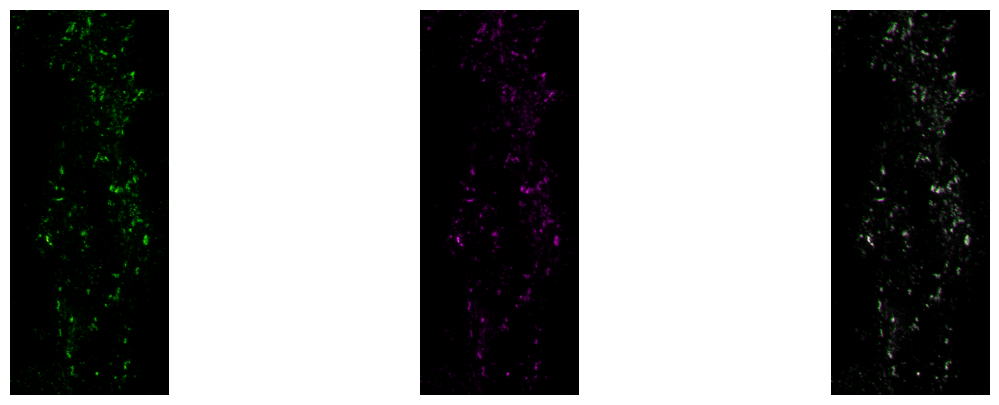

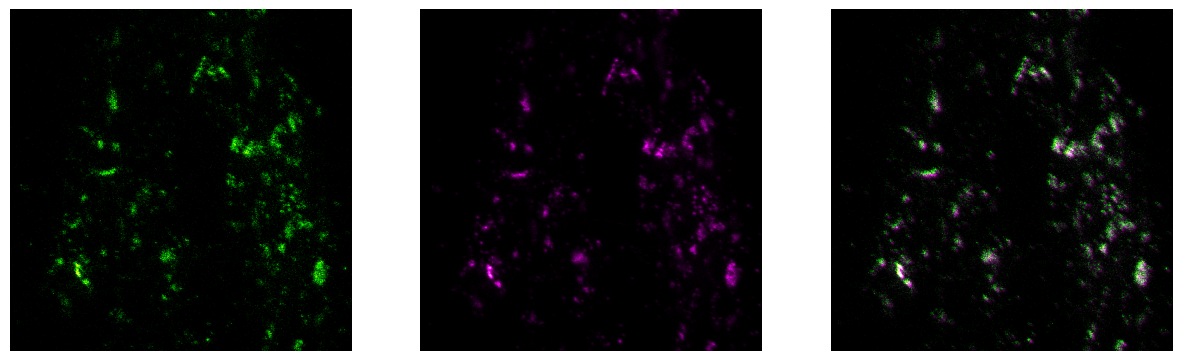

-------
itk::simple::TranslationTransform
 TranslationTransform (0x558da170aa30)
   RTTI typeinfo:   itk::TranslationTransform<double, 2u>
   Reference Count: 2
   Modified Time: 9488
   Debug: Off
   Object Name: 
   Observers: 
     none
   Offset: [-3.29223, -3.12893]

Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 15 iterations. Current step (0.0078125) is less than minimum step (0.01).
 Iteration: 16
 Metric value: 24.8221648756954
(1420, 585)


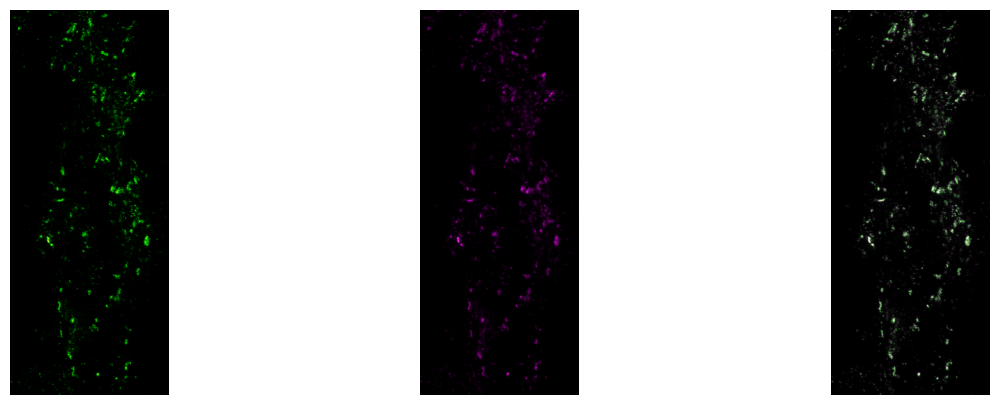

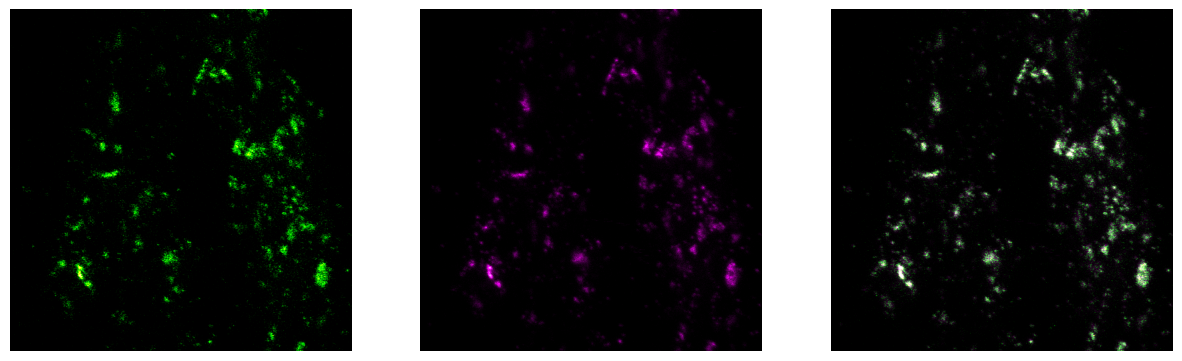

In [53]:
import random
random.shuffle(files)
for file in files:
    images = tifffile.imread(file)

    images = images.astype("float32")

    fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(make_composite(images[0:1], ["Green Hot"]))
    axes[1].imshow(make_composite(images[1:2], ["Magenta Hot"]))
    axes[2].imshow(make_composite(images, ["Green Hot", "Magenta Hot"]))
    for ax in axes:
        ax.axis('off')
    pyplot.show()

    
    cy, cx = numpy.array(images[0].shape) // 2
    slc = tuple(
        slice(max(0, c - 256), min(s, c + 256)) for c, s in zip((cy, cx), images[0].shape)
    )

    fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(make_composite(images[0:1, slc[0], slc[1]], ["Green Hot"]))
    axes[1].imshow(make_composite(images[1:2, slc[0], slc[1]], ["Magenta Hot"]))
    axes[2].imshow(make_composite(images[:, slc[0], slc[1]], ["Green Hot", "Magenta Hot"]))
    for ax in axes:
        ax.axis('off')
    pyplot.show()

    fixed_image = sitk.GetImageFromArray(images[1])
    moving_image = sitk.GetImageFromArray(images[0])

    R = sitk.ImageRegistrationMethod()
    R.SetMetricAsMeanSquares()
    R.SetOptimizerAsRegularStepGradientDescent(4.0, 0.01, 200)
    R.SetInitialTransform(sitk.TranslationTransform(fixed_image.GetDimension()))
    R.SetInterpolator(sitk.sitkLinear)
    outTx = R.Execute(fixed_image, moving_image)

    print("-------")
    print(outTx)
    print("Optimizer stop condition: {0}".format(R.GetOptimizerStopConditionDescription()))
    print(" Iteration: {0}".format(R.GetOptimizerIteration()))
    print(" Metric value: {0}".format(R.GetMetricValue()))

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed_image)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetTransform(outTx)
    out = resampler.Execute(moving_image)

    registered_image = sitk.GetArrayFromImage(out)
    print(registered_image.shape)
    fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(make_composite(registered_image[None, ...], ["Green Hot"]))
    axes[1].imshow(make_composite(images[1:2], ["Magenta Hot"]))
    axes[2].imshow(make_composite(numpy.stack([registered_image, images[1]]), ["Green Hot", "Magenta Hot"]))
    for ax in axes:
        ax.axis('off')
    pyplot.show()

    fig, axes = pyplot.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(make_composite(registered_image[slc[0], slc[1]][None, ...], ["Green Hot"]))
    axes[1].imshow(make_composite(images[1:2, slc[0], slc[1]], ["Magenta Hot"]))
    axes[2].imshow(make_composite(numpy.stack([registered_image[slc[0], slc[1]], images[1, slc[0], slc[1]]], axis=0), ["Green Hot", "Magenta Hot"]))
    for ax in axes:
        ax.axis('off')
    pyplot.show()

    break